# Content

In this notebook we detail the clustering of inner-iterations for the C implementation.
We show why we choose to use the last two iterations for the attack and show the results obtained by using the classical k-mean algorithm.

# Imports and Globals

Here are the python packages that must be available to run the script.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tools import *
from scipy.cluster.vq import whiten, kmeans2

In [2]:
# adapt here the pathes to your configuration (be sure directories exist)
curve_directory = './data'
tmp_directory = './tmp'
curve_filename  = 'bike_cortexm4_20_traces.npy'
curve_idx = 0
inner_decimation = 64

In [3]:
curves = np.load(os.path.join(curve_directory,curve_filename))[:20]
# The data here is read from the temporary directory.
# You have first to generate these files by running "Detection" notebooks.
outer_iterations_bounds = np.load(os.path.join(tmp_directory,'outer_iterations_bounds.npy'))

# Choice of the Outer-Iteration to Target

As explained in the reference paper, traces from the C implementation have a highly exploitable leakage mainly in the two last iterations. In this section of the notebook we compute clustering accuracies for all the outer-iterations.

## Nonzero Syndrome Outer-Iterations

In [4]:
inner_pattern = np.load(os.path.join(tmp_directory,'raw_inner_iteration_pattern_nonzero.npy'))

## Zero Syndrome Outer-Iterations

First we split the curve in 142 inner-iterations.

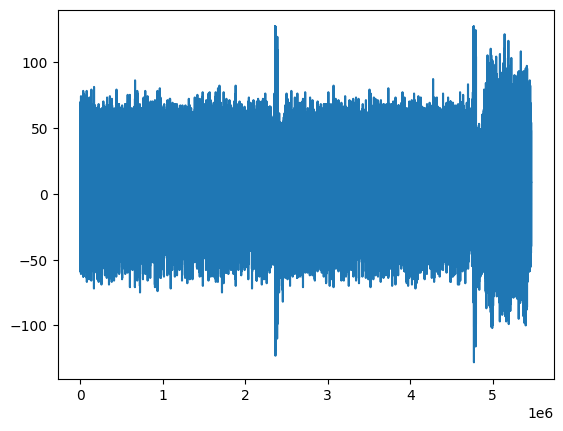

In [5]:
inner_pattern = np.load(os.path.join(tmp_directory,'raw_inner_iteration_pattern_zero.npy'))
sos=butter(4, 0.01, output='sos')
outer_curve = curves[curve_idx][outer_iterations_bounds[curve_idx][-3]:outer_iterations_bounds[curve_idx][-2]]
plt.plot(outer_curve)
plt.show()
proc_outer_curve = simplify_pattern(outer_curve, decimation=inner_decimation)
proc_inner_pattern = simplify_pattern(inner_pattern, decimation=inner_decimation)
pcc_inner = pearson_xcorr(proc_outer_curve,proc_inner_pattern)
inner_starts = detect_peaks_inner(np.abs(pcc_inner), threshold=0.91, min_gap=100, keep='max')
if len(inner_starts) == 140:
    new_peak1 = detect_first_peak(pcc_inner,inner_starts[:70])
    new_peak2 = detect_first_peak(pcc_inner,inner_starts[70:])
    inner_starts += [new_peak1 , new_peak2]
    inner_starts.sort()
inner_starts = inner_decimation * np.array(inner_starts)

In [6]:
print("\tNumber of peaks for outer-iteration: {}".format(len(inner_starts)))

	Number of peaks for outer-iteration: 142


In [7]:
min_pattern_length =  np.min(inner_starts[1:]-np.array(inner_starts[:-1]))
print("Minimum pattern length:",min_pattern_length)

Minimum pattern length: 28032


In [8]:
patterns = [ outer_curve[start:start+min_pattern_length] for start in inner_starts ]
patterns = np.array(patterns,dtype=float)

As already mentioned, the split is not perfect as can be seen on the average curve.

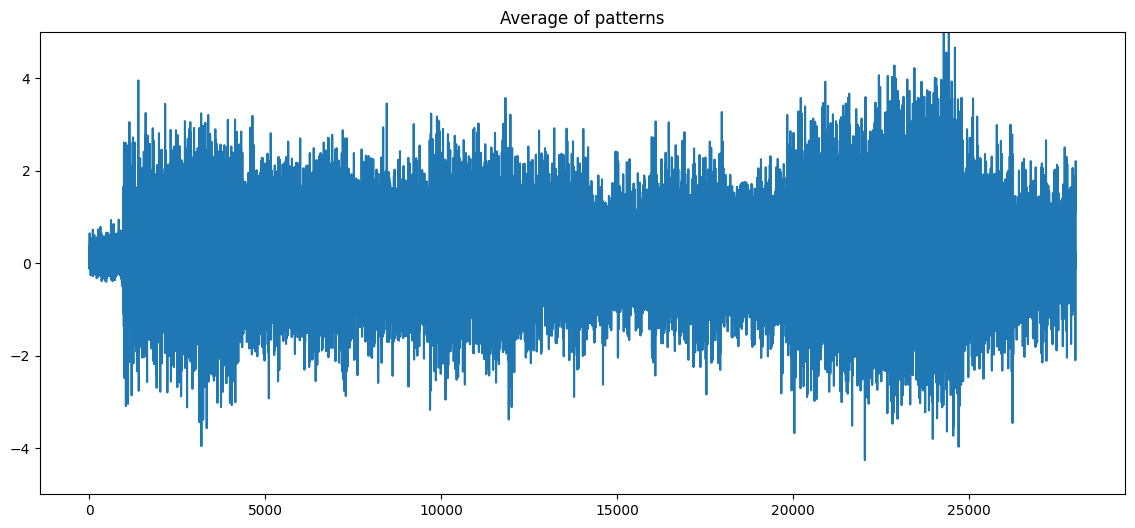

In [9]:
plt.figure(figsize=(14,6))
plt.ylim(-5,5)
plt.plot(np.mean(patterns,0))
plt.title('Average of patterns')
plt.show()

We will thus improve this by adjusting patterns with an offset as in the notebook `Inner-Iterations Detection (C implementation)`.

In [10]:
sync_patterns = sync_inner_patterns(patterns, pattern_length=min_pattern_length-2200, threshold=-14.0, tweaks={0:-25,71:-25})

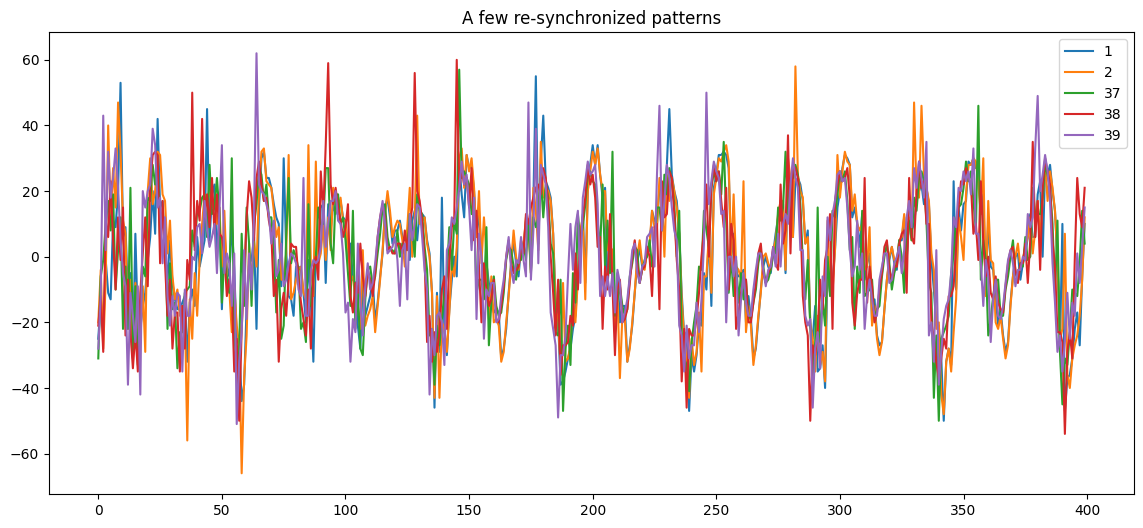

In [53]:
plt.figure(figsize=(14,6))
for i in [1,2,37,38,39]:
    plt.plot(sync_patterns[i][:400],label=str(i))
plt.title('A few re-synchronized patterns')
plt.legend()
plt.show()

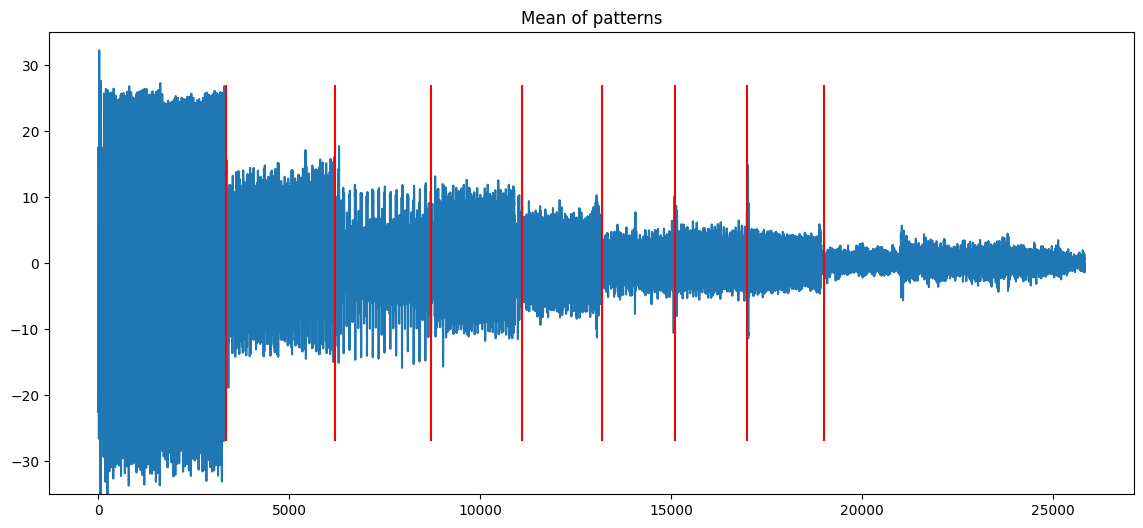

In [12]:
plt.figure(figsize=(14,6))
plt.ylim(-35,35)
plt.plot(np.mean(sync_patterns,0),zorder=1)
plt.vlines([3350,6200,8700,11100,13200,15100,17000,19000],ymin=-27,ymax=27,color='red',zorder=2)
plt.title('Mean of patterns')
plt.show()

Now we have perfectly aligned traces (or at least good enough). We also clearly see the different steps of the rotation that marked using red lines.

In [13]:
patterns_13 = sync_patterns[:,:3350]

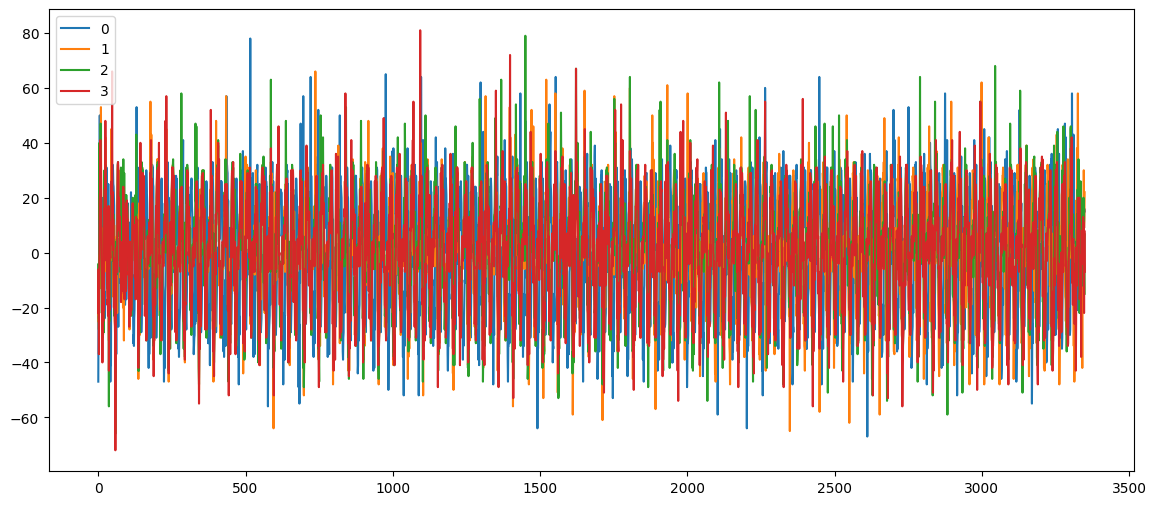

In [14]:
plt.figure(figsize=(14,6))

for i in [0,1,2,3]:
    plt.plot(patterns_13[i][:],label=str(i))
plt.legend()
plt.show()

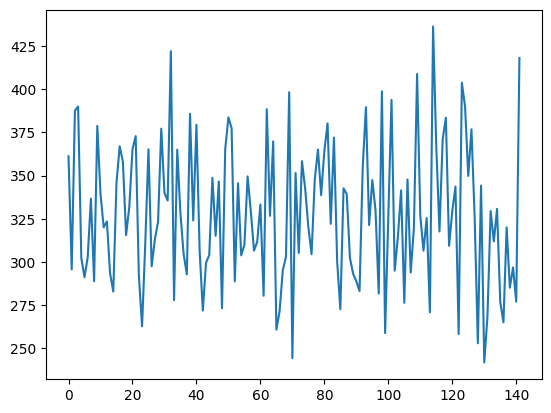

(array([], dtype=int64),)


In [15]:
v = []
for i in range(len(patterns_13)):
    v.append(np.var(patterns_13[i][:150]))
plt.plot(v)
plt.show()

print(np.where(np.array(v)>500))

In [34]:
h0_row = np.load(os.path.join(curve_directory,'h0_row.npy'))
h0_binary = []
for i in range(len(h0_row)):
    if h0_row[i] == 0:
        continue
    h0_binary.append([int(x, 2) for x in np.binary_repr(i, width=14)])
h0_binary = np.array(h0_binary)
print(h0_binary.shape)
np.save(os.path.join(curve_directory,'h0_binary.npy'), h0_binary)

h1_row = np.load(os.path.join(curve_directory,'h1_row.npy'))
h1_binary = []
for i in range(len(h1_row)):
    if h1_row[i] == 0:
        continue
    h1_binary.append([int(x, 2) for x in np.binary_repr(i, width=14)])
h1_binary = np.array(h1_binary)
print(h1_binary.shape)
np.save(os.path.join(curve_directory,'h1_binary.npy'), h1_binary)


(71, 14)
(71, 14)


In [48]:
from scipy.cluster.vq import whiten,kmeans2
indices = [ i for i in range(0,71) ]
print(len(patterns_13))
p = [ patterns_13[i][480:500] for i in indices ]

p -= np.mean(p,0)
p = whiten(p)

centroid, labels = kmeans2(p,2,iter=10,minit="points")
print(len(labels))
h0 = np.load(os.path.join(curve_directory,'h0_binary.npy'))
ref_13_h0 = h0[indices,0]
count = float((labels==ref_13_h0).sum()) / len(indices)
count_inv = float((labels!=ref_13_h0).sum()) / len(indices)
print(count)
print(count_inv)
print(ref_13_h0)
print(labels)
# print(max(count,count_inv))

142
71
0.36619718309859156
0.6338028169014085
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1 1 0 1 0 1 1 0 0 1
 0 0 0 0 0 1 1 1 0 1 0 0 0 0 1 0 1 1 1 1 1 1 0 0 1 0 1 0 1 1 1 1 0 0]


In [91]:
indices =  [ i for i in range(72,142) ]
p = [ patterns_13[i][:500] for i in indices ]

p -= np.mean(p,0)
p = whiten(p)

centroid, labels = kmeans2(p,2,iter=10,minit="points")
h1 = np.load(os.path.join(curve_directory,'h1_binary.npy'))
ref_13_h1 = h1[ [i-71 for i in indices],0]
count = float((labels==ref_13_h1).sum()) / len(indices)
print(max(count,1-count))

0.7


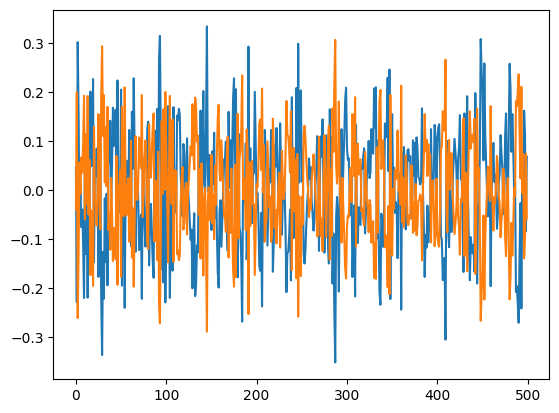

In [52]:
indices = [ i for i in range(0,71) ]
p = np.array([ patterns_13[i] for i in indices ])
p -= np.mean(p,0)
p = whiten(p)

h0 = np.load(os.path.join(curve_directory,'h0_binary.npy'))
i_0 = np.where(h0[indices,0]==0)[0]
i_1 = np.where(h0[indices,0]==1)[0]

plt.plot(np.mean(p[i_1],0)[:500])
plt.plot(np.mean(p[i_0],0)[:500])
plt.show()

## BIT 12

In [164]:
from scipy.cluster.vq import whiten,kmeans2
patterns_12 = sync_patterns[:,3350:3400]#3350:6200]

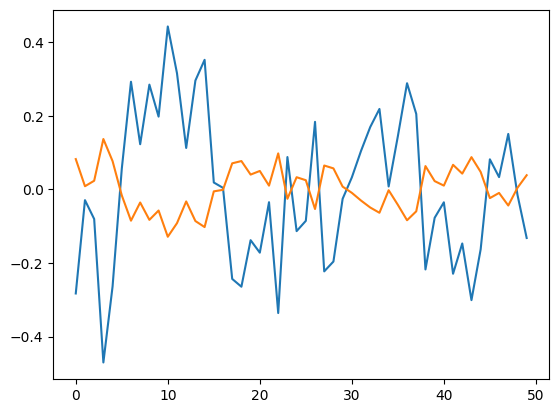

In [167]:
indices = [ i for i in range(0,71) ]
p = np.array([ patterns_12[i] for i in indices ])
p -= np.mean(p,0)
p = whiten(p)

h0 = np.load(os.path.join(curve_directory,'h0_binary.npy'))
i_0 = np.where(h0[indices,1]==0)[0]
i_1 = np.where(h0[indices,1]==1)[0]

plt.plot(np.mean(p[i_1],0)[:500])
plt.plot(np.mean(p[i_0],0)[:500])
plt.show()

In [151]:
indices = [ i for i in range(1,71) ]
p = [ patterns_12[i] for i in indices ]

p -= np.mean(p,0)
p = whiten(p)

centroid, labels = kmeans2(p,2,iter=10,minit="points")
h0 = np.load(os.path.join(curve_directory,'h0_binary.npy'))
ref_12_h0 = h0[indices,1]
count = float((labels==ref_12_h0).sum()) / len(indices)
print(max(count,1-count))

indices =  [ i for i in range(72,142) ]
p = [ patterns_12[i] for i in indices ]

p -= np.mean(p,0)
p = whiten(p)

centroid, labels = kmeans2(p,2,iter=10,minit="points")
h1 = np.load(os.path.join(curve_directory,'h1_binary.npy'))
ref_12_h1 = h1[ [i-71 for i in indices],1]
count = float((labels==ref_12_h1).sum()) / len(indices)
print(max(count,1-count))

0.9428571428571428
0.6428571428571428


In [204]:
from scipy.cluster.vq import whiten,kmeans2
centroid, labels = kmeans2(patterns_13,2,iter=10,minit="points")

In [205]:
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1], dtype=int32)

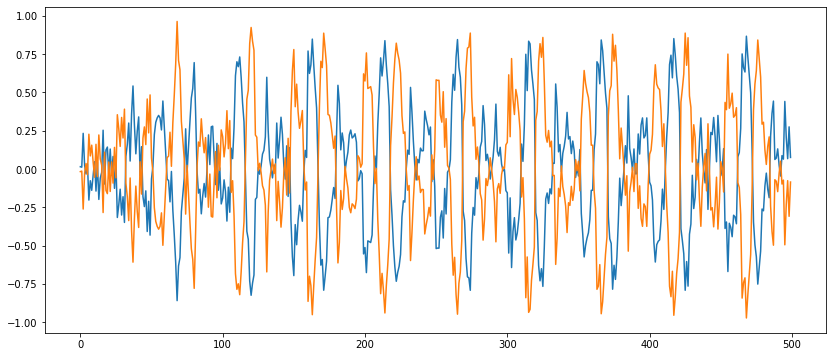

In [55]:
plt.figure(figsize=(14,6))
plt.plot(centroid[0][:500])
plt.plot(centroid[1][:500])
plt.show()

In [115]:
mask_13 = [1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1]
mask_13 =np.array(mask_13)
mask_12 =[0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0]
mask_12 =np.array(mask_12)
mask_11 =[1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,1,0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1,1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0,0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0]
mask_11 =np.array(mask_11)
mask_10 = [1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0]
mask_10 =np.array(mask_10)
mask_9 = [0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0]
mask_9 =np.array(mask_9)
mask_8 = [1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1]
mask_8 =np.array(mask_8)
mask_7 = [1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1]
mask_7 = np.array(mask_7)
mask_6 = [0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1]
mask_6 = np.array(mask_6)

In [121]:
len(mask_11)

284

In [5]:
h0 = np.load(os.path.join(curve_directory,'h0_binary.npy'))
print(h0.shape)

(71, 14)


In [7]:
print(h0[:,0])

[1 1 1 1 0 1 0 0 0 1 0 1 0 0 0 1 1 0 0 1 1 1 0 0 0 1 0 1 1 1 0 1 1 0 1 0 0
 0 0 0 1 0 0 1 0 0 0 1 0 1 1 1 0 1 1 0 1 0 1 0 0 0 1 0 1 0 0 0 1 1 0]


In [8]:
print(h0[:,1])

[0 0 0 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0
 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0 0 0 1 1 0 0 0]
